In [4]:
# Hafta 8


# Konu:
    ## Multi-head
    ## feedforward
    ## residual bağlantı
    ## LayerNorm


# Bu haftanın görevleri:
    ## Görev 1: Tek head'i multi-head attention'a çevir: aynı boyutu n_head tane küçük head'e böl, çıktıları birleştir. Val loss'u geçen haftaki tek head'le yan yana koy. (1:21:59 - 1:24:25)
    ## Görev 2: Transformer bloğunu parça parça tamamla: feedforward, residual bağlantı, LayerNorm. Her parçayı ekledikten sonra val loss'u kaydet. Tek tablo çıkar: bigram, tek head, multi-head, feedforward eklenmiş, residual eklenmiş, LayerNorm eklenmiş. LayerNorm'u hafta 6'da yazdığın BatchNorm1d ile karşılaştır: hangi eksende normalize ediyor, neden running_mean tutmuyor, kendi cümlelerinle yaz. (1:24:25 - 1:37:49)
    ## Görev 3: Modeli büyüt ve dropout ekle. Elindeki donanıma sığan bir konfigürasyon seç: n_embd, n_head, n_layer, block_size. Parametre sayısını, val loss'u ve eğitim süresini yaz, neden bu değerleri seçtiğini açıkla. Modelin ürettiği metinden bir örnek koy. (1:37:49 - 1:42:39)
    ## Görev 4: Aynı modeli Türkçe metinle eğit. Metni kendin derle, Tiny Shakespeare'e yakın boyutta olsun (yaklaşık 1 MB). Kaynaklardaki Vikikaynak'tan başlayabilirsin. Ürettiği metinden örnek ver. Türkçe metnin kaç farklı karakteri var, Shakespeare'inkiyle karşılaştır. İki val loss'u doğrudan karşılaştırabilir misin, neden, yaz.


In [5]:
# hazırlık
import torch

import torch.nn as nn
from torch.nn import functional as F


# veriyi oku
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)


# tokenzer (encode, decode)
stoi = {ch: idx for idx,ch in enumerate(chars)}
itos = {idx: ch for idx,ch in enumerate(chars)}

def encode(text):
    encoding = []
    for char in text:
        encoding.append(stoi[char])

    return encoding

def decode(text):
    decoding = []
    for num in text:
        decoding.append(itos[num])
    return "".join(decoding)

encode_text = encode("Merhaba Freya!")
decode_text = decode(encode_text)
print(f"Encode text: {encode_text}")
print(f"Decode text: {decode_text}")


# veriyi %90-10 split et
data = torch.tensor(encode(text), dtype=torch.long)
n = int(9*(len(data)/10))
X_tr  = data[:n]
X_val = data[n:]

Encode text: [25, 43, 56, 46, 39, 40, 39, 1, 18, 56, 43, 63, 39, 2]
Decode text: Merhaba Freya!


## Nihai amaç
![Attention Mimarisi](attention_architecture.png)

In [6]:
# hafta 7'deki kod



batch_size = 32
block_size = 8
max_iters = 5000
eval_interval = 500
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 32
n_head = 4
n_layer = 4
dropout = 0.0


# attention head
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self,x):
        B,T,C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # ben C yerine head_size koydum
        wei = (q @ k.transpose(-2,-1)) * (k.shape[-1] ** -0.5)

        tril = torch.tril(torch.ones(T, T))
        #wei = torch.zeros((T,T))
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        out = wei @ v

        return out



## bazı değişiklikler yapıcaz, ondan bunu yeniden yazıyoruz
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.pos_embedding_table = nn.Embedding(block_size,n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.sa_head = Head(n_embd)


    def forward(self,idx,targets=None):
        """
        # Ana Fikir Bu:
        logits = self.embedding_lookup_table(idx) # input  ---- embedding ---- > output
        loss = F.cross_entropy(logits, targets)
        """
        B,T = idx.shape

        token_emb = self.token_embedding_table(idx)
        pos_emb = self.pos_embedding_table(torch.arange(T, device=device))
        emb = token_emb + pos_emb
        emb = self.sa_head(emb)
        logits = self.lm_head(emb)

        if targets == None:
            loss = None
        else:
            ## B: batch (örnek) sayısı
            ## T: block_size
                ### wavenet te kaç grup olduğu idi
            ## C: channel
                ### her bir harf kaç boyutlu?
                ### output:vocab_size yaptık diye burda vocab_size kadar direkt
                    #### ara layer olsa, n_emb kadar olurdu boyutu
            B,T,C = logits.shape

            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)

        return logits,loss


    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the prediction
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def get_batch(split):
    data = X_tr if split == 'train' else X_val
    idx = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([data[i:i+block_size] for i in idx])
    y = torch.stack([data[i+1:i+block_size+1] for i in idx])

    # İŞTE EKSİK OLAN SATIR BU: Verileri de Ekran Kartına (CUDA) gönderiyoruz!
    x, y = x.to(device), y.to(device)

    return x, y


def train():
    model = BigramLanguageModel()
    m = model.to(device)
    # print the number of parameters in the model
    print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

    # create a PyTorch optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    for iter in range(max_iters):

        # every once in a while evaluate the loss on train and val sets
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss(model)
            print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        # sample a batch of data
        xb, yb = get_batch('train')

        # evaluate the loss
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # generate from the model
    context = torch.zeros((1, 1), dtype=torch.long, device=device)

    # decode'dan dönen listeyi tek bir string olarak birleştirip yazdırıyoruz
    generated_chars = decode(m.generate(context, max_new_tokens=2000)[0].tolist())
    print(''.join(generated_chars))

train()

0.007553 M parameters
step 0: train loss 4.2546, val loss 4.2556
step 500: train loss 2.6284, val loss 2.6381
step 1000: train loss 2.4970, val loss 2.5017
step 1500: train loss 2.4533, val loss 2.4665
step 2000: train loss 2.4344, val loss 2.4433
step 2500: train loss 2.4091, val loss 2.4360
step 3000: train loss 2.4160, val loss 2.4230
step 3500: train loss 2.4042, val loss 2.4108
step 4000: train loss 2.3870, val loss 2.3995
step 4500: train loss 2.3970, val loss 2.4088
step 4999: train loss 2.3750, val loss 2.3899

JIINGANTGUSCAy ben sun,
Thatr cat noveclthit y;
Warem, msito Lirs ten tho stert thon harnvestep a mee thave? ITI I marfady osouswen thing ile to presind ber wimar rt y hed hay as, marlom,
Col ut anno inge t my, wome peanile Go I itheco dart rd ns?
O malordelliser pars onien.

Hy tankil, yondes secrl
By, thas mey iariothad al
lese ofo derd whet!
Sel'dert menid dne hil leriest ghor ows ther prit wifoleacead,

ARTELERYV:
A doencut me, no ith nito,
PI myo whe and
D
QUENELOMI

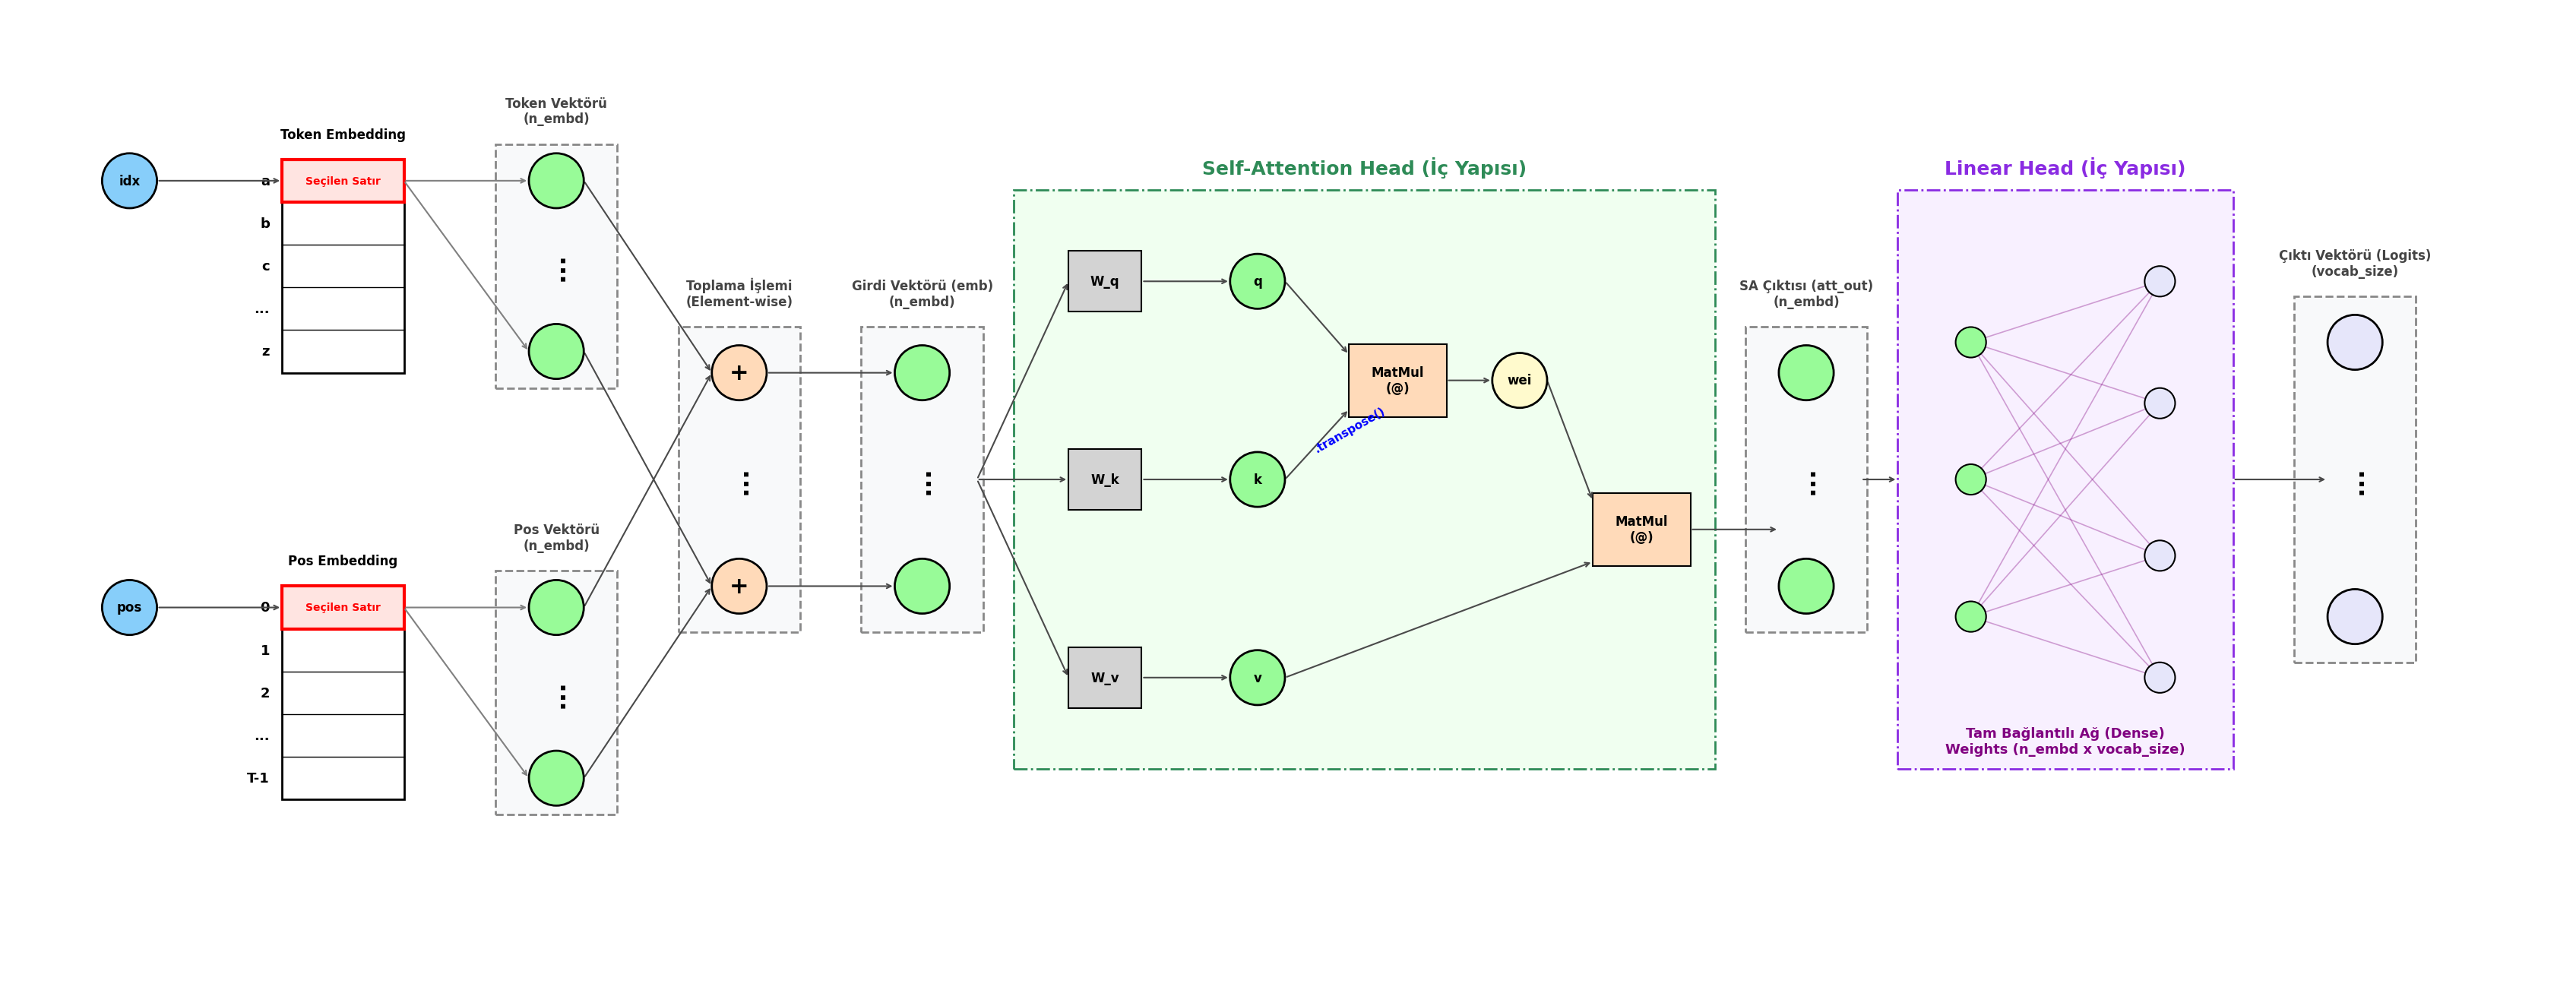

In [11]:
# görselleştirme


import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Her şeyi sığdırmak için devasa, ultra-geniş bir çizim alanı
fig, ax = plt.subplots(figsize=(34, 14))
ax.axis('off')

# Çizim sınırları
ax.set_xlim(0, 42)
ax.set_ylim(0, 16)
ax.set_aspect('equal')

r = 0.45
arr = dict(arrowstyle="->", color="#4a4a4a", lw=1.5)

# ================= YARDIMCI FONKSİYONLAR =================
def draw_node(ax, x, y, text, color, fontsize=12):
    ax.add_patch(patches.Circle((x, y), r, color=color, ec='black', lw=2, zorder=4))
    if text:
        ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=5)

def draw_small_node(ax, x, y, color):
    ax.add_patch(patches.Circle((x, y), 0.25, color=color, ec='black', lw=1.5, zorder=4))

def draw_box(ax, x, y, w, h, text, color):
    ax.add_patch(patches.Rectangle((x - w/2, y - h/2), w, h, ec='black', fc=color, lw=1.5, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=12, fontweight='bold', zorder=5)

# Nöronların etrafını saran Katman (Layer) Kutuları
def draw_layer_box(ax, x_center, y_center, w, h, text):
    ax.add_patch(patches.Rectangle((x_center - w/2, y_center - h/2), w, h, ec='#888888', fc='#f8f9fa', lw=2, ls='--', zorder=1))
    ax.text(x_center, y_center + h/2 + 0.3, text, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')

# Matris Çizici
def draw_emb_matrix(ax, x, y_bot, w, h, title, labels, hl_idx, hl_text):
    ax.add_patch(patches.Rectangle((x, y_bot), w, h, ec='black', fc='white', lw=2, zorder=2))
    n_rows = len(labels)
    row_h = h / n_rows
    for i in range(1, n_rows):
        ax.plot([x, x + w], [y_bot + i*row_h, y_bot + i*row_h], color='black', lw=1, zorder=2)
    for i, lbl in enumerate(reversed(labels)):
        ax.text(x - 0.2, y_bot + i*row_h + row_h/2, lbl, ha='right', va='center', fontsize=13, fontweight='bold')
    ax.text(x + w/2, y_bot + h + 0.3, title, ha='center', va='bottom', fontsize=12, fontweight='bold')

    hy = y_bot + (n_rows - 1 - hl_idx) * row_h
    ax.add_patch(patches.Rectangle((x, hy), w, row_h, ec='red', fc='#ffe4e1', lw=3, zorder=3))
    ax.text(x + w/2, hy + row_h/2, hl_text, ha='center', va='center', fontsize=10, color='red', fontweight='bold', zorder=5)
    return hy + row_h/2

# ================= 1. GİRDİLER VE MATRİSLER =================
mat_x, mat_w, mat_h = 4.5, 2.0, 3.5

ty = draw_emb_matrix(ax, mat_x, 10.0, mat_w, mat_h, "Token Embedding", ['a', 'b', 'c', '...', 'z'], 0, "Seçilen Satır")
py = draw_emb_matrix(ax, mat_x, 3.0, mat_w, mat_h, "Pos Embedding", ['0', '1', '2', '...', 'T-1'], 0, "Seçilen Satır")

draw_node(ax, 2.0, ty, "idx", '#87CEFA')
draw_node(ax, 2.0, py, "pos", '#87CEFA')

ax.annotate('', xy=(mat_x, ty), xytext=(2.0+r, ty), arrowprops=arr)
ax.annotate('', xy=(mat_x, py), xytext=(2.0+r, py), arrowprops=arr)

# ================= 2. VEKTÖR KATMANLARI (Nöron Grupları) =================
t_y_bot, p_y_bot = 10.35, 3.35
layer_w = 2.0

# Token Katmanı Kutusu
draw_layer_box(ax, 9.0, 11.75, layer_w, 4.0, "Token Vektörü\n(n_embd)")
draw_node(ax, 9.0, ty, "", '#98FB98')
draw_node(ax, 9.0, t_y_bot, "", '#98FB98')
ax.text(9.0, 11.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Pos Katmanı Kutusu
draw_layer_box(ax, 9.0, 4.75, layer_w, 4.0, "Pos Vektörü\n(n_embd)")
draw_node(ax, 9.0, py, "", '#98FB98')
draw_node(ax, 9.0, p_y_bot, "", '#98FB98')
ax.text(9.0, 4.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Matristen Vektöre Oklar
ax.annotate('', xy=(9.0-r, ty), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(9.0-r, t_y_bot), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(9.0-r, py), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(9.0-r, p_y_bot), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# ================= 3. TOPLAMA İŞLEMİ VEKTÖRÜ =================
# Toplama Katmanı Kutusu
draw_layer_box(ax, 12.0, 8.25, layer_w, 5.0, "Toplama İşlemi\n(Element-wise)")
draw_node(ax, 12.0, 10.0, "+", '#FFDAB9', fontsize=22)
draw_node(ax, 12.0, 6.5, "+", '#FFDAB9', fontsize=22)
ax.text(12.0, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Çapraz Toplama Okları (Token ve Pos Uç uca ekleniyor)
ax.annotate('', xy=(12.0-r, 10.0), xytext=(9.0+r, ty), arrowprops=arr)
ax.annotate('', xy=(12.0-r, 10.0), xytext=(9.0+r, py), arrowprops=arr)
ax.annotate('', xy=(12.0-r, 6.5), xytext=(9.0+r, t_y_bot), arrowprops=arr)
ax.annotate('', xy=(12.0-r, 6.5), xytext=(9.0+r, p_y_bot), arrowprops=arr)

# ================= 4. GİRDİ (EMB) VEKTÖRÜ =================
draw_layer_box(ax, 15.0, 8.25, layer_w, 5.0, "Girdi Vektörü (emb)\n(n_embd)")
draw_node(ax, 15.0, 10.0, "", '#98FB98')
draw_node(ax, 15.0, 6.5, "", '#98FB98')
ax.text(15.0, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(15.0-r, 10.0), xytext=(12.0+r, 10.0), arrowprops=arr)
ax.annotate('', xy=(15.0-r, 6.5), xytext=(12.0+r, 6.5), arrowprops=arr)

# ================= 5. DETAYLI SELF-ATTENTION HEAD (Devasa Kutu) =================
# Ana SA Çerçevesi
ax.add_patch(patches.Rectangle((16.5, 3.5), 11.5, 9.5, ec='#2e8b57', fc='#f0fff0', lw=2, ls='-.', zorder=0))
ax.text(22.25, 13.2, "Self-Attention Head (İç Yapısı)", ha='center', va='bottom', fontsize=18, fontweight='bold', color='#2e8b57')

# Girdi'den Q, K, V Dallanması
ax.annotate('', xy=(17.4, 11.5), xytext=(15.9, 8.25), arrowprops=arr)
ax.annotate('', xy=(17.4, 8.25), xytext=(15.9, 8.25), arrowprops=arr)
ax.annotate('', xy=(17.4, 5.0), xytext=(15.9, 8.25), arrowprops=arr)

# Linear Q, K, V ağırlıkları
draw_box(ax, 18.0, 11.5, 1.2, 1.0, "W_q", '#D3D3D3')
draw_box(ax, 18.0, 8.25, 1.2, 1.0, "W_k", '#D3D3D3')
draw_box(ax, 18.0, 5.0, 1.2, 1.0, "W_v", '#D3D3D3')

# Q, K, V Nöronları
draw_node(ax, 20.5, 11.5, "q", '#98FB98')
draw_node(ax, 20.5, 8.25, "k", '#98FB98')
draw_node(ax, 20.5, 5.0, "v", '#98FB98')

ax.annotate('', xy=(20.5-r, 11.5), xytext=(18.6, 11.5), arrowprops=arr)
ax.annotate('', xy=(20.5-r, 8.25), xytext=(18.6, 8.25), arrowprops=arr)
ax.annotate('', xy=(20.5-r, 5.0), xytext=(18.6, 5.0), arrowprops=arr)

# 1. MatMul (Q @ K.T)
draw_box(ax, 22.8, 9.875, 1.6, 1.2, "MatMul\n(@)", '#FFDAB9')
ax.annotate('', xy=(22.0, 10.3), xytext=(20.5+r, 11.5), arrowprops=arr)
ax.annotate('', xy=(22.0, 9.4), xytext=(20.5+r, 8.25), arrowprops=arr)
ax.text(21.4, 8.7, ".transpose()", rotation=30, fontsize=11, color='blue', fontweight='bold')

# Wei (Ağırlıklar)
draw_node(ax, 24.8, 9.875, "wei", '#FFFACD')
ax.annotate('', xy=(24.8-r, 9.875), xytext=(23.6, 9.875), arrowprops=arr)

# 2. MatMul (Wei @ V)
draw_box(ax, 26.8, 7.43, 1.6, 1.2, "MatMul\n(@)", '#FFDAB9')
ax.annotate('', xy=(26.0, 7.9), xytext=(24.8+r, 9.875), arrowprops=arr)
ax.annotate('', xy=(26.0, 6.9), xytext=(20.5+r, 5.0), arrowprops=arr)

# ================= 6. SA ÇIKIŞI (att_out) =================
draw_layer_box(ax, 29.5, 8.25, layer_w, 5.0, "SA Çıktısı (att_out)\n(n_embd)")
draw_node(ax, 29.5, 10.0, "", '#98FB98')
draw_node(ax, 29.5, 6.5, "", '#98FB98')
ax.text(29.5, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# SA Kutusundan çıkış
ax.annotate('', xy=(29.5-r, 7.43), xytext=(27.6, 7.43), arrowprops=arr)

# ================= 7. DETAYLI LINEAR HEAD (Devasa Kutu) =================
# Ana Linear Çerçevesi
ax.add_patch(patches.Rectangle((31.0, 3.5), 5.5, 9.5, ec='#8a2be2', fc='#f8f0ff', lw=2, ls='-.', zorder=0))
ax.text(33.75, 13.2, "Linear Head (İç Yapısı)", ha='center', va='bottom', fontsize=18, fontweight='bold', color='#8a2be2')

# att_out'tan Linear'e giriş
ax.annotate('', xy=(31.0, 8.25), xytext=(30.4, 8.25), arrowprops=arr)

# Dense (Fully Connected) Katman Çizimi
dense_in = 32.2
dense_out = 35.3
iy_list = [10.5, 8.25, 6.0]
oy_list = [11.5, 9.5, 7.0, 5.0]

# Herkesten-Herkese Bağlantı Çizgileri (Ağ Yapısı)
for iy in iy_list:
    for oy in oy_list:
        ax.plot([dense_in, dense_out], [iy, oy], color='purple', alpha=0.35, lw=1.2, zorder=2)

# Nöronlar
for iy in iy_list:
    draw_small_node(ax, dense_in, iy, '#98FB98')
for oy in oy_list:
    draw_small_node(ax, dense_out, oy, '#E6E6FA')

ax.text(33.75, 4.2, "Tam Bağlantılı Ağ (Dense)\nWeights (n_embd x vocab_size)", ha='center', va='top', fontsize=13, fontweight='bold', color='purple')

# ================= 8. LOGITS (OUTPUT) =================
draw_layer_box(ax, 38.5, 8.25, layer_w, 6.0, "Çıktı Vektörü (Logits)\n(vocab_size)")
draw_node(ax, 38.5, 10.5, "", '#E6E6FA')
draw_node(ax, 38.5, 6.0, "", '#E6E6FA')
ax.text(38.5, 8.25, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

# Linear'dan Çıkış
ax.annotate('', xy=(38.5-r, 8.25), xytext=(36.5, 8.25), arrowprops=arr)


plt.tight_layout()
plt.show()



In [7]:
# Görev 1:
    ## Tek head'i multi-head attention'a çevir
    ## Aynı boyutu n_head tane küçük head'e böl, çıktıları birleştir.
    ## Val loss'u geçen haftaki tek head'le yan yana koy



class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for x in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self, x):
        return torch.cat([h(x) for h in self.heads], dim=-1)


## bazı değişiklikler yapıcaz, ondan bunu yeniden yazıyoruz
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.pos_embedding_table = nn.Embedding(block_size,n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.sa_heads = MultiHeadAttention(4, n_embd // 4)


    def forward(self,idx,targets=None):
        """
        # Ana Fikir Bu:
        logits = self.embedding_lookup_table(idx) # input  ---- embedding ---- > output
        loss = F.cross_entropy(logits, targets)
        """
        B,T = idx.shape

        token_emb = self.token_embedding_table(idx)
        pos_emb = self.pos_embedding_table(torch.arange(T, device=device))
        emb = token_emb + pos_emb
        emb = self.sa_heads(emb)
        logits = self.lm_head(emb)

        if targets == None:
            loss = None
        else:
            ## B: batch (örnek) sayısı
            ## T: block_size
                ### wavenet te kaç grup olduğu idi
            ## C: channel
                ### her bir harf kaç boyutlu?
                ### output:vocab_size yaptık diye burda vocab_size kadar direkt
                    #### ara layer olsa, n_emb kadar olurdu boyutu
            B,T,C = logits.shape

            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)

        return logits,loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the prediction
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx


train()

0.008609 M parameters
step 0: train loss 4.2431, val loss 4.2471
step 500: train loss 2.6889, val loss 2.6934
step 1000: train loss 2.5398, val loss 2.5373
step 1500: train loss 2.4666, val loss 2.4887
step 2000: train loss 2.4248, val loss 2.4317
step 2500: train loss 2.3963, val loss 2.4077
step 3000: train loss 2.3587, val loss 2.3802
step 3500: train loss 2.3350, val loss 2.3658
step 4000: train loss 2.3160, val loss 2.3427
step 4500: train loss 2.3025, val loss 2.3209
step 4999: train loss 2.2883, val loss 2.3008

Teret ne spitl thaniteleteldst rerave whou ary lorddt homuser lith:
Esn?

So the chaw theand erfretr eatmpor set,
Hin se.

The.

Saivent tor dor waskepatert nated herw;

Fhisouse theen
An:
The?

Ro:
Pe exm!
Thay
Mepethingsbives'gle, tyes, andre a wou lithsp codsas cang:
The be; amart ing cole all sere eprsterwil seccomough,
LIOGewtnd, enot.

Persal take thin thersur theeat hit souhe,
This yeoult.

Theritle,
Him! your gherd ind ssothithin, Haing my wolithtcedl.

Fth thes 

| Single-head Attention (Geçen Hafta) | Multi-head Attention (Bu Hafta) |
| :---: | :---: |
| val loss: 2.3899 | val loss: 2.3008 |


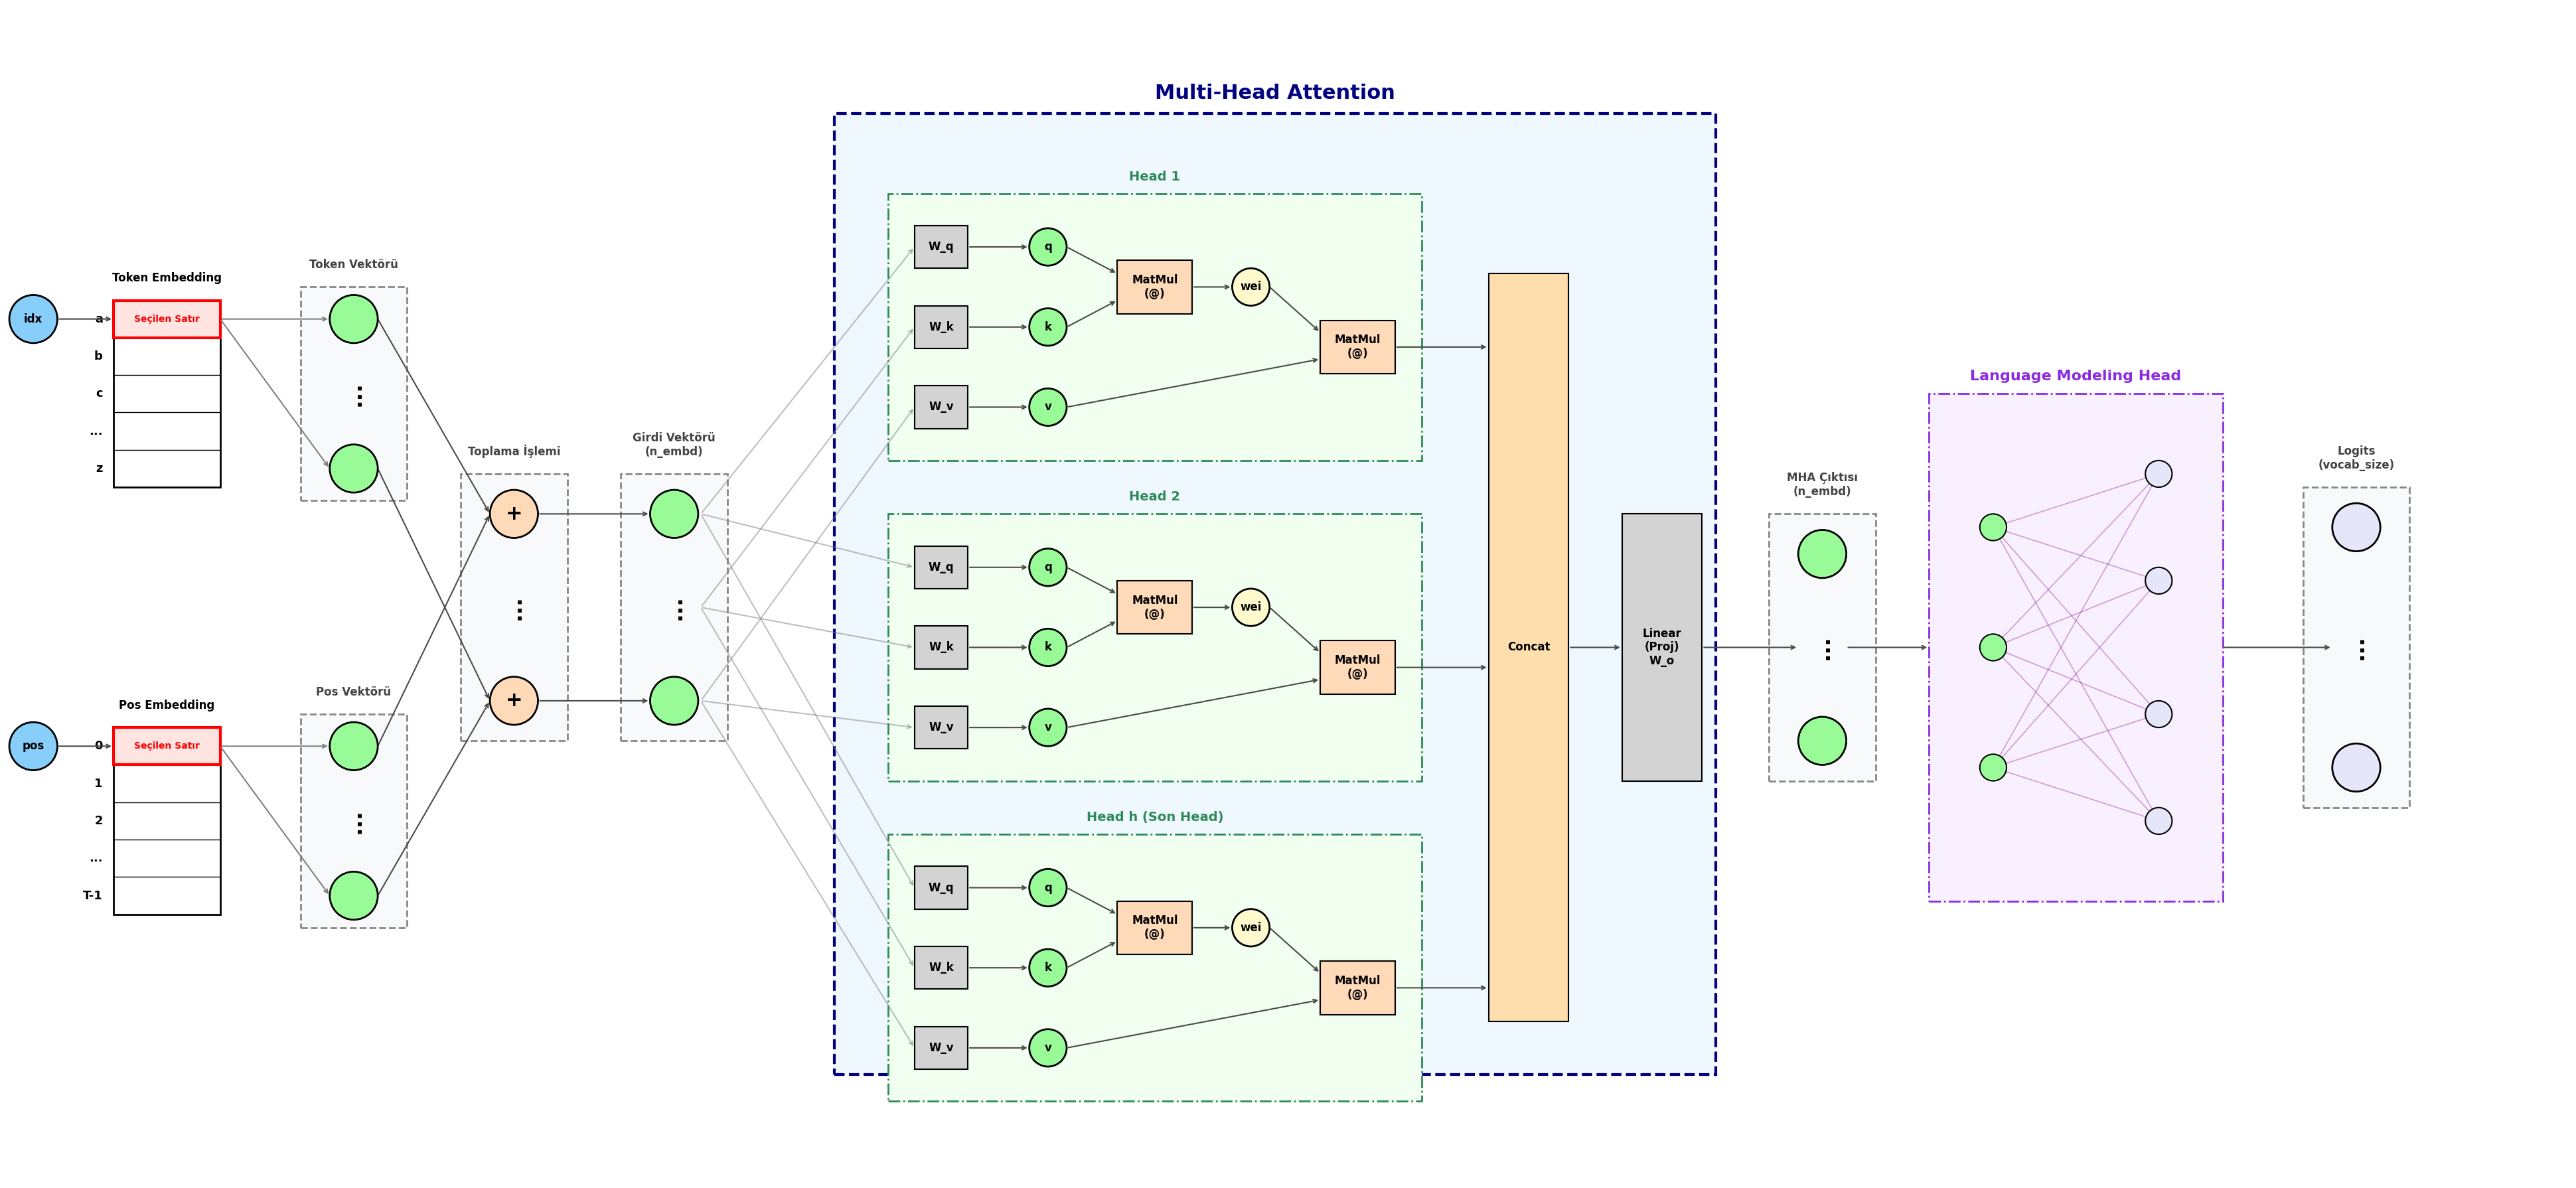

In [12]:
# görselleştirme (Multi-Head Attention)

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Her şeyi sığdırmak için devasa, ultra-geniş bir çizim alanı
fig, ax = plt.subplots(figsize=(42, 18))
ax.axis('off')

# Çizim sınırları
ax.set_xlim(0, 48)
ax.set_ylim(0, 22)
ax.set_aspect('equal')

r = 0.45
arr = dict(arrowstyle="->", color="#4a4a4a", lw=1.5)

# ================= YARDIMCI FONKSİYONLAR =================
def draw_node(ax, x, y, text, color, fontsize=12, radius=0.45):
    ax.add_patch(patches.Circle((x, y), radius, color=color, ec='black', lw=2, zorder=4))
    if text:
        ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=5)

def draw_small_node(ax, x, y, color):
    ax.add_patch(patches.Circle((x, y), 0.25, color=color, ec='black', lw=1.5, zorder=4))

def draw_box(ax, x, y, w, h, text, color):
    ax.add_patch(patches.Rectangle((x - w/2, y - h/2), w, h, ec='black', fc=color, lw=1.5, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=12, fontweight='bold', zorder=5)

def draw_layer_box(ax, x_center, y_center, w, h, text):
    ax.add_patch(patches.Rectangle((x_center - w/2, y_center - h/2), w, h, ec='#888888', fc='#f8f9fa', lw=2, ls='--', zorder=1))
    ax.text(x_center, y_center + h/2 + 0.3, text, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')

def draw_emb_matrix(ax, x, y_bot, w, h, title, labels, hl_idx, hl_text):
    ax.add_patch(patches.Rectangle((x, y_bot), w, h, ec='black', fc='white', lw=2, zorder=2))
    n_rows = len(labels)
    row_h = h / n_rows
    for i in range(1, n_rows):
        ax.plot([x, x + w], [y_bot + i*row_h, y_bot + i*row_h], color='black', lw=1, zorder=2)
    for i, lbl in enumerate(reversed(labels)):
        ax.text(x - 0.2, y_bot + i*row_h + row_h/2, lbl, ha='right', va='center', fontsize=13, fontweight='bold')
    ax.text(x + w/2, y_bot + h + 0.3, title, ha='center', va='bottom', fontsize=12, fontweight='bold')
    hy = y_bot + (n_rows - 1 - hl_idx) * row_h
    ax.add_patch(patches.Rectangle((x, hy), w, row_h, ec='red', fc='#ffe4e1', lw=3, zorder=3))
    ax.text(x + w/2, hy + row_h/2, hl_text, ha='center', va='center', fontsize=10, color='red', fontweight='bold', zorder=5)
    return hy + row_h/2

def draw_head(ax, x, y, title):
    # Ana Head Çerçevesi
    ax.add_patch(patches.Rectangle((x, y - 2.5), 10.0, 5.0, ec='#2e8b57', fc='#f0fff0', lw=2, ls='-.', zorder=0))
    ax.text(x + 5.0, y + 2.7, title, ha='center', va='bottom', fontsize=14, fontweight='bold', color='#2e8b57')

    # Linear Q, K, V ağırlıkları
    draw_box(ax, x + 1.0, y + 1.5, 1.0, 0.8, "W_q", '#D3D3D3')
    draw_box(ax, x + 1.0, y, 1.0, 0.8, "W_k", '#D3D3D3')
    draw_box(ax, x + 1.0, y - 1.5, 1.0, 0.8, "W_v", '#D3D3D3')

    # Q, K, V Nöronları
    draw_node(ax, x + 3.0, y + 1.5, "q", '#98FB98', radius=0.35)
    draw_node(ax, x + 3.0, y, "k", '#98FB98', radius=0.35)
    draw_node(ax, x + 3.0, y - 1.5, "v", '#98FB98', radius=0.35)

    ax.annotate('', xy=(x+3.0-0.35, y+1.5), xytext=(x+1.5, y+1.5), arrowprops=arr)
    ax.annotate('', xy=(x+3.0-0.35, y), xytext=(x+1.5, y), arrowprops=arr)
    ax.annotate('', xy=(x+3.0-0.35, y-1.5), xytext=(x+1.5, y-1.5), arrowprops=arr)

    # 1. MatMul (Q @ K.T)
    draw_box(ax, x + 5.0, y + 0.75, 1.4, 1.0, "MatMul\n(@)", '#FFDAB9')
    ax.annotate('', xy=(x+4.3, y+1.0), xytext=(x+3.35, y+1.5), arrowprops=arr)
    ax.annotate('', xy=(x+4.3, y+0.5), xytext=(x+3.35, y), arrowprops=arr)

    # Wei
    draw_node(ax, x + 6.8, y + 0.75, "wei", '#FFFACD', radius=0.35)
    ax.annotate('', xy=(x+6.45, y+0.75), xytext=(x+5.7, y+0.75), arrowprops=arr)

    # 2. MatMul (Wei @ V)
    draw_box(ax, x + 8.8, y - 0.375, 1.4, 1.0, "MatMul\n(@)", '#FFDAB9')
    ax.annotate('', xy=(x+8.1, y-0.1), xytext=(x+7.15, y+0.75), arrowprops=arr)
    ax.annotate('', xy=(x+8.1, y-0.6), xytext=(x+3.35, y-1.5), arrowprops=arr)

    return x + 9.5, y - 0.375

# ================= 1. GİRDİLER VE MATRİSLER =================
mat_x, mat_w, mat_h = 2.0, 2.0, 3.5
ty = draw_emb_matrix(ax, mat_x, 13.0, mat_w, mat_h, "Token Embedding", ['a', 'b', 'c', '...', 'z'], 0, "Seçilen Satır")
py = draw_emb_matrix(ax, mat_x, 5.0, mat_w, mat_h, "Pos Embedding", ['0', '1', '2', '...', 'T-1'], 0, "Seçilen Satır")

draw_node(ax, 0.5, ty, "idx", '#87CEFA')
draw_node(ax, 0.5, py, "pos", '#87CEFA')
ax.annotate('', xy=(mat_x, ty), xytext=(0.5+r, ty), arrowprops=arr)
ax.annotate('', xy=(mat_x, py), xytext=(0.5+r, py), arrowprops=arr)

# ================= 2. VEKTÖR KATMANLARI =================
t_y_bot, p_y_bot = 13.35, 5.35
layer_w = 2.0
draw_layer_box(ax, 6.5, 14.75, layer_w, 4.0, "Token Vektörü")
draw_node(ax, 6.5, ty, "", '#98FB98')
draw_node(ax, 6.5, t_y_bot, "", '#98FB98')
ax.text(6.5, 14.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

draw_layer_box(ax, 6.5, 6.75, layer_w, 4.0, "Pos Vektörü")
draw_node(ax, 6.5, py, "", '#98FB98')
draw_node(ax, 6.5, p_y_bot, "", '#98FB98')
ax.text(6.5, 6.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(6.5-r, ty), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(6.5-r, t_y_bot), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(6.5-r, py), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(6.5-r, p_y_bot), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# ================= 3. TOPLAMA İŞLEMİ =================
draw_layer_box(ax, 9.5, 10.75, layer_w, 5.0, "Toplama İşlemi")
draw_node(ax, 9.5, 12.5, "+", '#FFDAB9', fontsize=22)
draw_node(ax, 9.5, 9.0, "+", '#FFDAB9', fontsize=22)
ax.text(9.5, 10.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(9.5-r, 12.5), xytext=(6.5+r, ty), arrowprops=arr)
ax.annotate('', xy=(9.5-r, 12.5), xytext=(6.5+r, py), arrowprops=arr)
ax.annotate('', xy=(9.5-r, 9.0), xytext=(6.5+r, t_y_bot), arrowprops=arr)
ax.annotate('', xy=(9.5-r, 9.0), xytext=(6.5+r, p_y_bot), arrowprops=arr)

# ================= 4. GİRDİ (EMB) VEKTÖRÜ =================
draw_layer_box(ax, 12.5, 10.75, layer_w, 5.0, "Girdi Vektörü\n(n_embd)")
draw_node(ax, 12.5, 12.5, "", '#98FB98')
draw_node(ax, 12.5, 9.0, "", '#98FB98')
ax.text(12.5, 10.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(12.5-r, 12.5), xytext=(9.5+r, 12.5), arrowprops=arr)
ax.annotate('', xy=(12.5-r, 9.0), xytext=(9.5+r, 9.0), arrowprops=arr)

# ================= 5. MULTI-HEAD ATTENTION =================
# Ana Çerçeve
ax.add_patch(patches.Rectangle((15.5, 2.0), 16.5, 18.0, ec='navy', fc='#f0f8ff', lw=3, ls='--', zorder=-1))
ax.text(23.75, 20.2, "Multi-Head Attention", ha='center', va='bottom', fontsize=22, fontweight='bold', color='navy')

# Head'leri Çiz
head_x = 16.5
out1_x, out1_y = draw_head(ax, head_x, 16.0, "Head 1")
out2_x, out2_y = draw_head(ax, head_x, 10.0, "Head 2")
out3_x, out3_y = draw_head(ax, head_x, 4.0, "Head h (Son Head)")

# Girdi Vektöründen Head'lere Oklar
# Head 1
ax.annotate('', xy=(head_x+0.5, 17.5), xytext=(13.0, 12.5), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 16.0), xytext=(13.0, 10.75), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 14.5), xytext=(13.0, 9.0), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
# Head 2
ax.annotate('', xy=(head_x+0.5, 11.5), xytext=(13.0, 12.5), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 10.0), xytext=(13.0, 10.75), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 8.5), xytext=(13.0, 9.0), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
# Head 3
ax.annotate('', xy=(head_x+0.5, 5.5), xytext=(13.0, 12.5), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 4.0), xytext=(13.0, 10.75), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 2.5), xytext=(13.0, 9.0), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))

# ================= 6. CONCAT & LINEAR =================
# Concat Kutusu
draw_box(ax, 28.5, 10.0, 1.5, 14.0, "Concat", '#FFDEAD')

# Head'lerden Concat'e Oklar
ax.annotate('', xy=(27.75, 15.625), xytext=(out1_x, out1_y), arrowprops=arr)
ax.annotate('', xy=(27.75, 9.625), xytext=(out2_x, out2_y), arrowprops=arr)
ax.annotate('', xy=(27.75, 3.625), xytext=(out3_x, out3_y), arrowprops=arr)

# Linear Projection Kutusu (W_o)
draw_box(ax, 31.0, 10.0, 1.5, 5.0, "Linear\n(Proj)\nW_o", '#D3D3D3')
ax.annotate('', xy=(30.25, 10.0), xytext=(29.25, 10.0), arrowprops=arr)

# ================= 7. SA ÇIKTISI (att_out) =================
draw_layer_box(ax, 34.0, 10.0, layer_w, 5.0, "MHA Çıktısı\n(n_embd)")
draw_node(ax, 34.0, 11.75, "", '#98FB98')
draw_node(ax, 34.0, 8.25, "", '#98FB98')
ax.text(34.0, 10.0, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')
ax.annotate('', xy=(34.0-r, 10.0), xytext=(31.75, 10.0), arrowprops=arr)

# ================= 8. LINEAR HEAD (Dense) =================
ax.add_patch(patches.Rectangle((36.0, 5.25), 5.5, 9.5, ec='#8a2be2', fc='#f8f0ff', lw=2, ls='-.', zorder=0))
ax.text(38.75, 14.95, "Language Modeling Head", ha='center', va='bottom', fontsize=16, fontweight='bold', color='#8a2be2')

ax.annotate('', xy=(36.0, 10.0), xytext=(34.0+r, 10.0), arrowprops=arr)

dense_in = 37.2
dense_out = 40.3
iy_list = [12.25, 10.0, 7.75]
oy_list = [13.25, 11.25, 8.75, 6.75]

for iy in iy_list:
    for oy in oy_list:
        ax.plot([dense_in, dense_out], [iy, oy], color='purple', alpha=0.35, lw=1.2, zorder=2)

for iy in iy_list:
    draw_small_node(ax, dense_in, iy, '#98FB98')
for oy in oy_list:
    draw_small_node(ax, dense_out, oy, '#E6E6FA')

# ================= 9. LOGITS (OUTPUT) =================
draw_layer_box(ax, 44.0, 10.0, layer_w, 6.0, "Logits\n(vocab_size)")
draw_node(ax, 44.0, 12.25, "", '#E6E6FA')
draw_node(ax, 44.0, 7.75, "", '#E6E6FA')
ax.text(44.0, 10.0, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(44.0-r, 10.0), xytext=(41.5, 10.0), arrowprops=arr)

plt.tight_layout()
plt.show()

![Multi-Head Attention Mimarisi](attention_heads.png)

In [8]:
# Görev 2: Transformer bloğunu parça parça tamamla
    ## Şunları ekle:
        ### feedforward
        ### residual bağlantı
        ### LayerNorm
    ## Her parçayı ekledikten sonra val loss'u kaydet - Tek tablo çıkar:
        ### Bigram
        ### Single-head
        ### multi-head
        ### Feedforward eklenmiş
        ### Residual eklenmiş
        ### LayerNorm eklenmiş
    ## LayerNorm'u hafta 6'da yazdığın BatchNorm1d ile karşılaştır
    ## Kendi cümlelerinle yaz
        ### Hangi eksende normalize ediyor?
        ### Neden running_mean tutmuyor?





##############################################
################ FEEDFORWARD
##############################################
print("\n\n\n\nFeedforward")

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, n_embd* 4),
            nn.ReLU(),
            nn.Linear(n_embd*4, n_embd),
            nn.ReLU(),
        )

    def forward(self,x):
        return self.net(x)


## bazı değişiklikler yapıcaz, ondan bunu yeniden yazıyoruz
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.pos_embedding_table = nn.Embedding(block_size,n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.sa_heads = MultiHeadAttention(4, n_embd // 4)
        self.ffwd = FeedForward(n_embd)


    def forward(self,idx,targets=None):
        """
        # Ana Fikir Bu:
        logits = self.embedding_lookup_table(idx) # input  ---- embedding ---- > output
        loss = F.cross_entropy(logits, targets)
        """
        B,T = idx.shape

        token_emb = self.token_embedding_table(idx)
        pos_emb = self.pos_embedding_table(torch.arange(T, device=device))
        x = token_emb + pos_emb
        x = self.sa_heads(x)
        # attention'dan geçtikten sonra, MLP'den geçerdi ya... onu ekledik
        x = self.ffwd(x)
        logits = self.lm_head(x)

        if targets == None:
            loss = None
        else:
            ## B: batch (örnek) sayısı
            ## T: block_size
                ### wavenet te kaç grup olduğu idi
            ## C: channel
                ### her bir harf kaç boyutlu?
                ### output:vocab_size yaptık diye burda vocab_size kadar direkt
                    #### ara layer olsa, n_emb kadar olurdu boyutu
            B,T,C = logits.shape

            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)

        return logits,loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the prediction
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx




train()

##############################################
################ RESIDUAL
##############################################
print("\n\n\n\nResidual")

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()

        head_size = n_embd // n_head
        self.heads = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)

    def forward(self,x):
        # Residual connection bu " 'x +' ..."lı kısım
        x = x + self.heads(x)
        x = x + self.ffwd(x)
        return x


## bazı değişiklikler yapıcaz, ondan bunu yeniden yazıyoruz
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.pos_embedding_table = nn.Embedding(block_size,n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        """
        self.sa_heads = MultiHeadAttention(4, n_embd // 4)
        self.ffwd = FeedForward(n_embd)
        """
        self.blocks = nn.Sequential(
            Block(n_embd, 4),
            Block(n_embd, 4),
            Block(n_embd, 4),
        )

    def forward(self,idx,targets=None):
        """
        # Ana Fikir Bu:
        logits = self.embedding_lookup_table(idx) # input  ---- embedding ---- > output
        loss = F.cross_entropy(logits, targets)
        """
        B,T = idx.shape

        token_emb = self.token_embedding_table(idx)
        pos_emb = self.pos_embedding_table(torch.arange(T, device=device))
        x = token_emb + pos_emb

        """
        x = self.sa_heads(x)
        x = self.ffwd(x)
        """

        x = self.blocks(x)
        logits = self.lm_head(x)

        if targets == None:
            loss = None
        else:
            ## B: batch (örnek) sayısı
            ## T: block_size
                ### wavenet te kaç grup olduğu idi
            ## C: channel
                ### her bir harf kaç boyutlu?
                ### output:vocab_size yaptık diye burda vocab_size kadar direkt
                    #### ara layer olsa, n_emb kadar olurdu boyutu
            B,T,C = logits.shape

            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)

        return logits,loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the prediction
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx




train()







##############################################
################ LAYER NORM
##############################################
print("\n\n\n\nLayer Norm")

# Paper'daki mimaride, "Multi-Head Attention"dan sonra "Add & Norm" geliyordu ya... o bu
class LayerNorm(nn.Module):
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        super().__init__()
        self.eps = eps

        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))


    def forward(self,x):
        xmean = x.mean(-1,keepdim=True)
        xvar  = x.var(-1,keepdim=True)
        self.out = self.gamma * ( (x - xmean) / torch.sqrt(xvar + self.eps) ) + self.beta
        return self.out



class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()

        head_size = n_embd // n_head
        self.heads = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = LayerNorm(n_embd)
        self.ln2 = LayerNorm(n_embd)

    def forward(self,x):
        # artık (initial paper'ın aksine) hem önce hem sonra uygulanur layerNorm
            ## bu, sonraki layernorm
        x = x + self.heads(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


## bazı değişiklikler yapıcaz, ondan bunu yeniden yazıyoruz
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.pos_embedding_table = nn.Embedding(block_size,n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        """
        self.sa_heads = MultiHeadAttention(4, n_embd // 4)
        self.ffwd = FeedForward(n_embd)
        """
        self.blocks = nn.Sequential(
            Block(n_embd, 4),
            Block(n_embd, 4),
            Block(n_embd, 4),
            # artık (initial paper'ın aksine) hem önce hem sonra uygulanur layerNorm
                ## bu, sonraki layernorm
            LayerNorm(n_embd)
        )

    def forward(self,idx,targets=None):
        """
        # Ana Fikir Bu:
        logits = self.embedding_lookup_table(idx) # input  ---- embedding ---- > output
        loss = F.cross_entropy(logits, targets)
        """
        B,T = idx.shape

        token_emb = self.token_embedding_table(idx)
        pos_emb = self.pos_embedding_table(torch.arange(T, device=device))
        x = token_emb + pos_emb

        """
        x = self.sa_heads(x)
        x = self.ffwd(x)
        """

        x = self.blocks(x)
        logits = self.lm_head(x)

        if targets == None:
            loss = None
        else:
            ## B: batch (örnek) sayısı
            ## T: block_size
                ### wavenet te kaç grup olduğu idi
            ## C: channel
                ### her bir harf kaç boyutlu?
                ### output:vocab_size yaptık diye burda vocab_size kadar direkt
                    #### ara layer olsa, n_emb kadar olurdu boyutu
            B,T,C = logits.shape

            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)

        return logits,loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the prediction
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx




train()





Feedforward
0.016961 M parameters
step 0: train loss 4.1839, val loss 4.1842
step 500: train loss 2.5139, val loss 2.5171
step 1000: train loss 2.3995, val loss 2.3976
step 1500: train loss 2.3386, val loss 2.3389
step 2000: train loss 2.2927, val loss 2.2904
step 2500: train loss 2.2393, val loss 2.2577
step 3000: train loss 2.2168, val loss 2.2366
step 3500: train loss 2.1799, val loss 2.2297
step 4000: train loss 2.1680, val loss 2.2014
step 4500: train loss 2.1642, val loss 2.2005
step 4999: train loss 2.1452, val loss 2.1915

KENING ERIZMETTIO:
ARD VIE:
Hell grud!
Whens gool'd ep; bur.

PEBROLIUCARV:
Out thee, oue wach lover; grod hat ind ca th, by, thench os is,
Pre gook the pemy,
be he sut punt; frok a thaveds Myou the a bue od noth ears.

Shain, les wrign: hou the rocumperanse; of the, I rou an.

KENISTE:
Novere hed
Ond, awn afe to not she bef woud gande ong rin, as uncaly thed To mar mades
The to shis, my we Twill:
Thy hat shat unce?
DROME Wite plans trand sened! a ro? cal

| Model / Mimari Aşaması | Validation Loss |
| :--- | :---: |
| **Bigram** | 2.4543 |
| **Single-head Attention** | 2.3899 |
| **Multi-head Attention** | 2.3008 |
| **Feedforward Eklenmiş** | 2.1915 |
| **Residual Eklenmiş** | 2.1369 |
| **LayerNorm Eklenmiş** | 2.0783 |


  ## Hangi eksende normalize ediyor?
  * BatchNorm: dim=0
    - (B,T,C)'deki B
  * LayerNorm: dim=-1 (dim=2 yani)
    - (B,T,C)'deki C

  ## LayerNorm neden running_mean tutmuyor?
  * BatchNorm, B ekseninde hesap yapıyor... ondan tutmak zorunda
  * LayerNorm, C ekseninde hesap yapıyor... ondan tutmasına gerek yok
    - Testte B=1 ise bile (tek veri varsa) C tane özellik oluyor

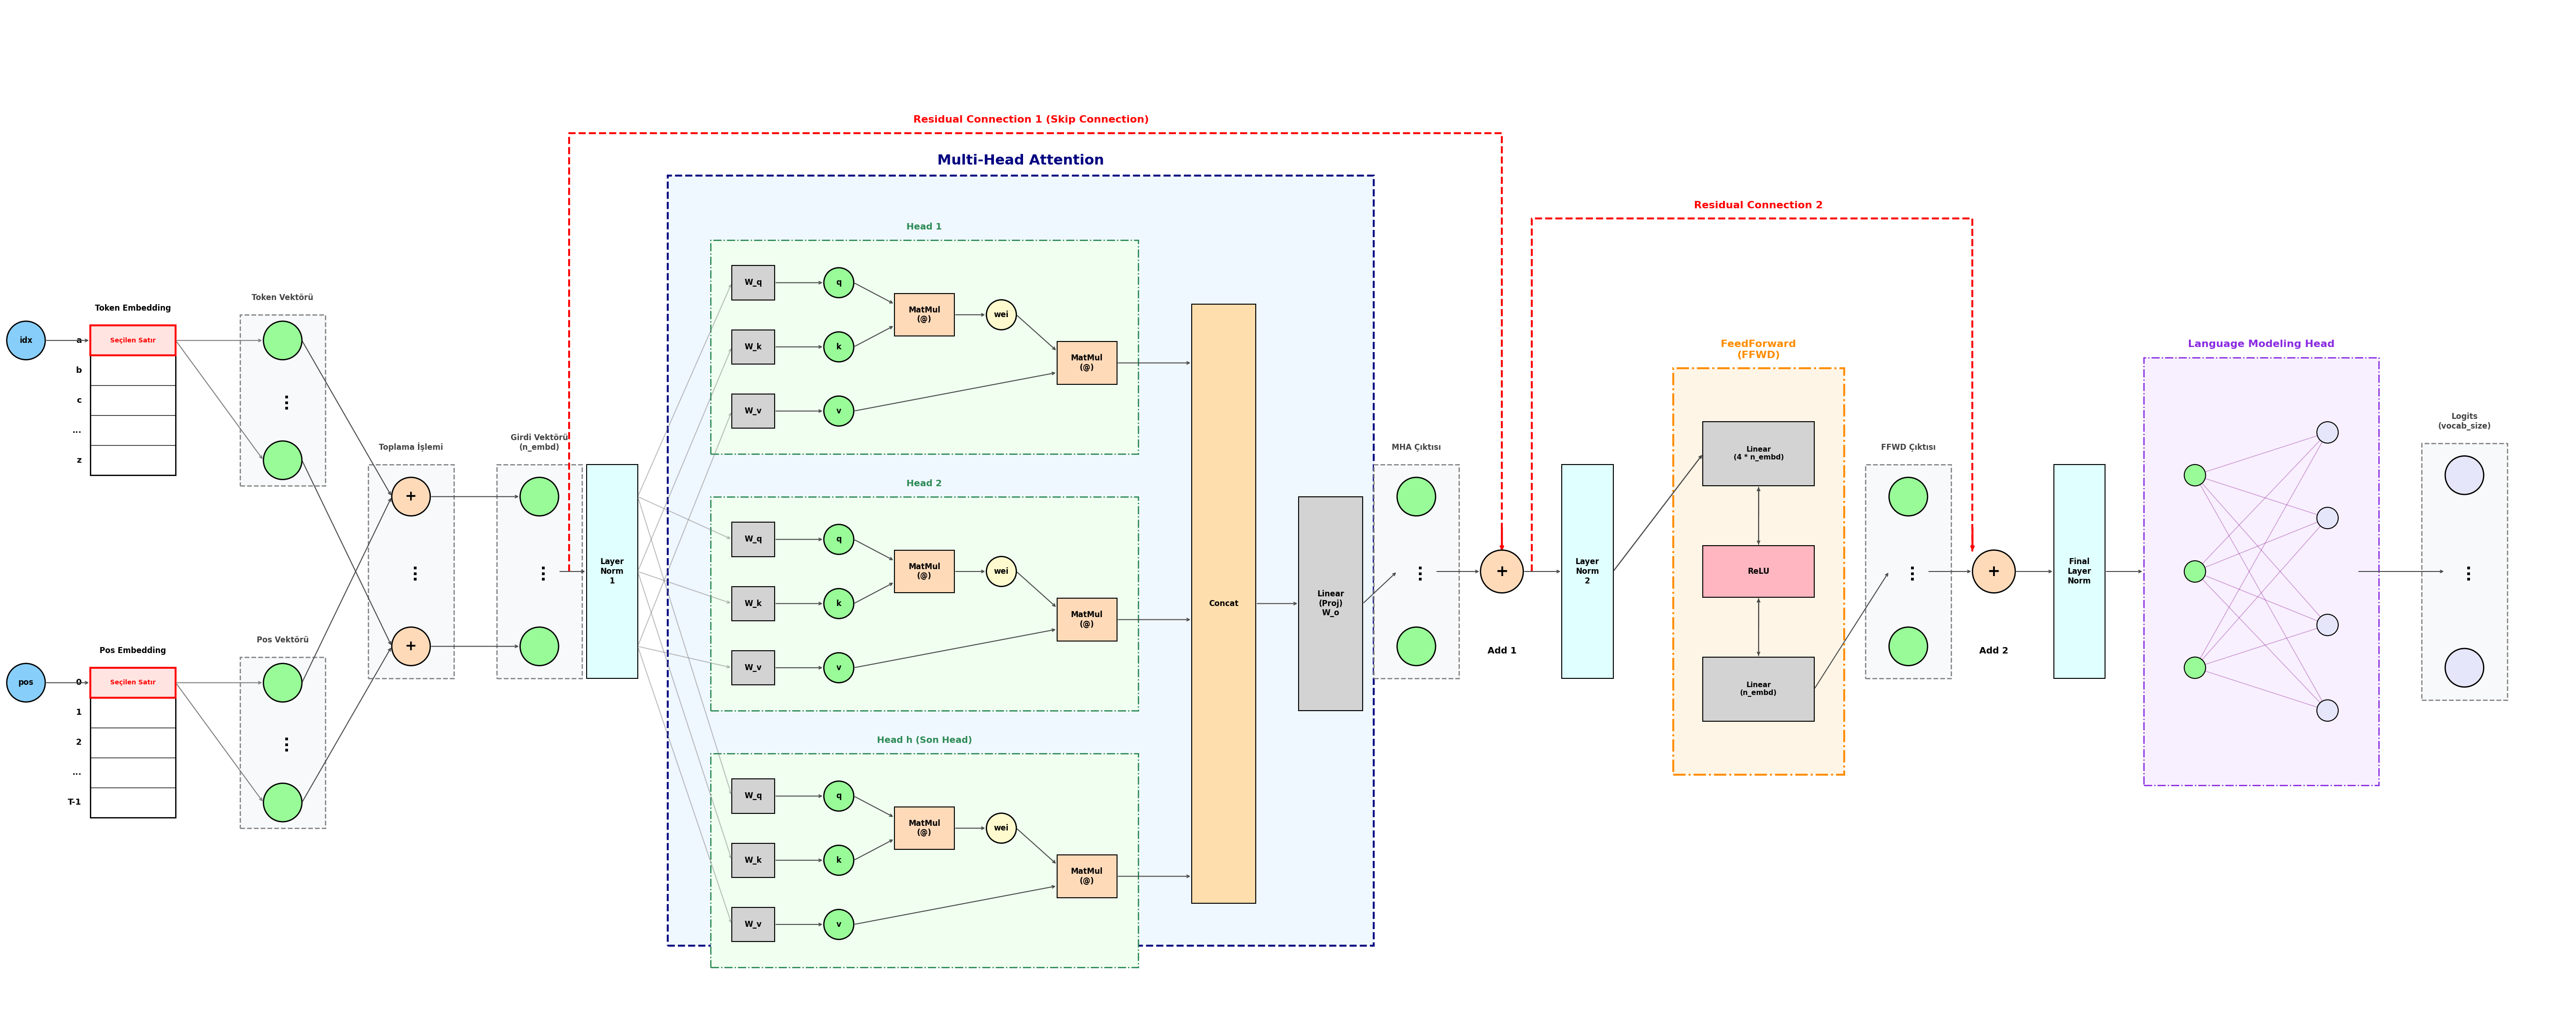

In [13]:
# görselleştirme (Tam Transformer Bloğu: MHA + FFWD + Residuals + LayerNorms)

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Her şeyi sığdırmak için DEVASA bir çizim alanı
fig, ax = plt.subplots(figsize=(56, 24))
ax.axis('off')

# Çizim sınırları
ax.set_xlim(0, 60)
ax.set_ylim(0, 24)
ax.set_aspect('equal')

r = 0.45
arr = dict(arrowstyle="->", color="#4a4a4a", lw=1.5)

# ================= YARDIMCI FONKSİYONLAR =================
def draw_node(ax, x, y, text, color, fontsize=12, radius=0.45):
    ax.add_patch(patches.Circle((x, y), radius, color=color, ec='black', lw=2, zorder=4))
    if text:
        ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=5)

def draw_small_node(ax, x, y, color):
    ax.add_patch(patches.Circle((x, y), 0.25, color=color, ec='black', lw=1.5, zorder=4))

def draw_box(ax, x, y, w, h, text, color, fontsize=12):
    ax.add_patch(patches.Rectangle((x - w/2, y - h/2), w, h, ec='black', fc=color, lw=1.5, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=5)

def draw_layer_box(ax, x_center, y_center, w, h, text):
    ax.add_patch(patches.Rectangle((x_center - w/2, y_center - h/2), w, h, ec='#888888', fc='#f8f9fa', lw=2, ls='--', zorder=1))
    ax.text(x_center, y_center + h/2 + 0.3, text, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')

def draw_emb_matrix(ax, x, y_bot, w, h, title, labels, hl_idx, hl_text):
    ax.add_patch(patches.Rectangle((x, y_bot), w, h, ec='black', fc='white', lw=2, zorder=2))
    n_rows = len(labels)
    row_h = h / n_rows
    for i in range(1, n_rows):
        ax.plot([x, x + w], [y_bot + i*row_h, y_bot + i*row_h], color='black', lw=1, zorder=2)
    for i, lbl in enumerate(reversed(labels)):
        ax.text(x - 0.2, y_bot + i*row_h + row_h/2, lbl, ha='right', va='center', fontsize=13, fontweight='bold')
    ax.text(x + w/2, y_bot + h + 0.3, title, ha='center', va='bottom', fontsize=12, fontweight='bold')
    hy = y_bot + (n_rows - 1 - hl_idx) * row_h
    ax.add_patch(patches.Rectangle((x, hy), w, row_h, ec='red', fc='#ffe4e1', lw=3, zorder=3))
    ax.text(x + w/2, hy + row_h/2, hl_text, ha='center', va='center', fontsize=10, color='red', fontweight='bold', zorder=5)
    return hy + row_h/2

def draw_head(ax, x, y, title):
    # Ana Head Çerçevesi
    ax.add_patch(patches.Rectangle((x, y - 2.5), 10.0, 5.0, ec='#2e8b57', fc='#f0fff0', lw=2, ls='-.', zorder=0))
    ax.text(x + 5.0, y + 2.7, title, ha='center', va='bottom', fontsize=14, fontweight='bold', color='#2e8b57')

    draw_box(ax, x + 1.0, y + 1.5, 1.0, 0.8, "W_q", '#D3D3D3')
    draw_box(ax, x + 1.0, y, 1.0, 0.8, "W_k", '#D3D3D3')
    draw_box(ax, x + 1.0, y - 1.5, 1.0, 0.8, "W_v", '#D3D3D3')

    draw_node(ax, x + 3.0, y + 1.5, "q", '#98FB98', radius=0.35)
    draw_node(ax, x + 3.0, y, "k", '#98FB98', radius=0.35)
    draw_node(ax, x + 3.0, y - 1.5, "v", '#98FB98', radius=0.35)

    ax.annotate('', xy=(x+3.0-0.35, y+1.5), xytext=(x+1.5, y+1.5), arrowprops=arr)
    ax.annotate('', xy=(x+3.0-0.35, y), xytext=(x+1.5, y), arrowprops=arr)
    ax.annotate('', xy=(x+3.0-0.35, y-1.5), xytext=(x+1.5, y-1.5), arrowprops=arr)

    draw_box(ax, x + 5.0, y + 0.75, 1.4, 1.0, "MatMul\n(@)", '#FFDAB9')
    ax.annotate('', xy=(x+4.3, y+1.0), xytext=(x+3.35, y+1.5), arrowprops=arr)
    ax.annotate('', xy=(x+4.3, y+0.5), xytext=(x+3.35, y), arrowprops=arr)

    draw_node(ax, x + 6.8, y + 0.75, "wei", '#FFFACD', radius=0.35)
    ax.annotate('', xy=(x+6.45, y+0.75), xytext=(x+5.7, y+0.75), arrowprops=arr)

    draw_box(ax, x + 8.8, y - 0.375, 1.4, 1.0, "MatMul\n(@)", '#FFDAB9')
    ax.annotate('', xy=(x+8.1, y-0.1), xytext=(x+7.15, y+0.75), arrowprops=arr)
    ax.annotate('', xy=(x+8.1, y-0.6), xytext=(x+3.35, y-1.5), arrowprops=arr)

    return x + 9.5, y - 0.375

# ================= 1. GİRDİLER VE MATRİSLER =================
mat_x, mat_w, mat_h = 2.0, 2.0, 3.5
ty = draw_emb_matrix(ax, mat_x, 13.0, mat_w, mat_h, "Token Embedding", ['a', 'b', 'c', '...', 'z'], 0, "Seçilen Satır")
py = draw_emb_matrix(ax, mat_x, 5.0, mat_w, mat_h, "Pos Embedding", ['0', '1', '2', '...', 'T-1'], 0, "Seçilen Satır")

draw_node(ax, 0.5, ty, "idx", '#87CEFA')
draw_node(ax, 0.5, py, "pos", '#87CEFA')
ax.annotate('', xy=(mat_x, ty), xytext=(0.5+r, ty), arrowprops=arr)
ax.annotate('', xy=(mat_x, py), xytext=(0.5+r, py), arrowprops=arr)

# ================= 2. VEKTÖR KATMANLARI =================
t_y_bot, p_y_bot = 13.35, 5.35
layer_w = 2.0
draw_layer_box(ax, 6.5, 14.75, layer_w, 4.0, "Token Vektörü")
draw_node(ax, 6.5, ty, "", '#98FB98')
draw_node(ax, 6.5, t_y_bot, "", '#98FB98')
ax.text(6.5, 14.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

draw_layer_box(ax, 6.5, 6.75, layer_w, 4.0, "Pos Vektörü")
draw_node(ax, 6.5, py, "", '#98FB98')
draw_node(ax, 6.5, p_y_bot, "", '#98FB98')
ax.text(6.5, 6.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(6.5-r, ty), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(6.5-r, t_y_bot), xytext=(mat_x+mat_w, ty), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(6.5-r, py), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.annotate('', xy=(6.5-r, p_y_bot), xytext=(mat_x+mat_w, py), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# ================= 3. TOPLAMA İŞLEMİ & GİRDİ =================
draw_layer_box(ax, 9.5, 10.75, layer_w, 5.0, "Toplama İşlemi")
draw_node(ax, 9.5, 12.5, "+", '#FFDAB9', fontsize=22)
draw_node(ax, 9.5, 9.0, "+", '#FFDAB9', fontsize=22)
ax.text(9.5, 10.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(9.5-r, 12.5), xytext=(6.5+r, ty), arrowprops=arr)
ax.annotate('', xy=(9.5-r, 12.5), xytext=(6.5+r, py), arrowprops=arr)
ax.annotate('', xy=(9.5-r, 9.0), xytext=(6.5+r, t_y_bot), arrowprops=arr)
ax.annotate('', xy=(9.5-r, 9.0), xytext=(6.5+r, p_y_bot), arrowprops=arr)

draw_layer_box(ax, 12.5, 10.75, layer_w, 5.0, "Girdi Vektörü\n(n_embd)")
draw_node(ax, 12.5, 12.5, "", '#98FB98')
draw_node(ax, 12.5, 9.0, "", '#98FB98')
ax.text(12.5, 10.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')
ax.annotate('', xy=(12.5-r, 12.5), xytext=(9.5+r, 12.5), arrowprops=arr)
ax.annotate('', xy=(12.5-r, 9.0), xytext=(9.5+r, 9.0), arrowprops=arr)

# ================= 4. RESIDUAL 1 & LAYERNORM 1 =================
# Residual 1 Çizgisi (Üstten dolanarak Add_1'e gider)
ax.plot([13.2, 13.2, 35.0, 35.0], [10.75, 21.0, 21.0, 11.2], color='red', lw=3, ls='--', zorder=1)
ax.annotate('', xy=(35.0, 11.2), xytext=(35.0, 11.8), arrowprops=dict(arrowstyle="->", color="red", lw=3))
ax.text(24.0, 21.2, "Residual Connection 1 (Skip Connection)", ha='center', va='bottom', color='red', fontweight='bold', fontsize=16)

# LayerNorm 1 Kutusu
draw_box(ax, 14.2, 10.75, 1.2, 5.0, "Layer\nNorm\n1", '#E0FFFF')
ax.annotate('', xy=(14.2-0.6, 10.75), xytext=(12.5+r, 10.75), arrowprops=arr)

# ================= 5. MULTI-HEAD ATTENTION =================
ax.add_patch(patches.Rectangle((15.5, 2.0), 16.5, 18.0, ec='navy', fc='#f0f8ff', lw=3, ls='--', zorder=-1))
ax.text(23.75, 20.2, "Multi-Head Attention", ha='center', va='bottom', fontsize=22, fontweight='bold', color='navy')

head_x = 16.5
out1_x, out1_y = draw_head(ax, head_x, 16.0, "Head 1")
out2_x, out2_y = draw_head(ax, head_x, 10.0, "Head 2")
out3_x, out3_y = draw_head(ax, head_x, 4.0, "Head h (Son Head)")

# LN1'den Head'lere Oklar
ax.annotate('', xy=(head_x+0.5, 17.5), xytext=(14.8, 12.5), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 16.0), xytext=(14.8, 10.75), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 14.5), xytext=(14.8, 9.0), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))

ax.annotate('', xy=(head_x+0.5, 11.5), xytext=(14.8, 12.5), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 10.0), xytext=(14.8, 10.75), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 8.5), xytext=(14.8, 9.0), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))

ax.annotate('', xy=(head_x+0.5, 5.5), xytext=(14.8, 12.5), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 4.0), xytext=(14.8, 10.75), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))
ax.annotate('', xy=(head_x+0.5, 2.5), xytext=(14.8, 9.0), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5))

# Concat Kutusu & Linear W_o
draw_box(ax, 28.5, 10.0, 1.5, 14.0, "Concat", '#FFDEAD')
ax.annotate('', xy=(27.75, 15.625), xytext=(out1_x, out1_y), arrowprops=arr)
ax.annotate('', xy=(27.75, 9.625), xytext=(out2_x, out2_y), arrowprops=arr)
ax.annotate('', xy=(27.75, 3.625), xytext=(out3_x, out3_y), arrowprops=arr)

draw_box(ax, 31.0, 10.0, 1.5, 5.0, "Linear\n(Proj)\nW_o", '#D3D3D3')
ax.annotate('', xy=(30.25, 10.0), xytext=(29.25, 10.0), arrowprops=arr)

# ================= 6. MHA ÇIKTISI & ADD (RESIDUAL 1) =================
draw_layer_box(ax, 33.0, 10.75, layer_w, 5.0, "MHA Çıktısı")
draw_node(ax, 33.0, 12.5, "", '#98FB98')
draw_node(ax, 33.0, 9.0, "", '#98FB98')
ax.text(33.0, 10.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')
ax.annotate('', xy=(33.0-r, 10.75), xytext=(31.75, 10.0), arrowprops=arr)

draw_node(ax, 35.0, 10.75, "+", '#FFDAB9', fontsize=24, radius=0.5)
ax.text(35.0, 9.0, "Add 1", ha='center', va='top', fontweight='bold', fontsize=14)
ax.annotate('', xy=(35.0-0.5, 10.75), xytext=(33.0+r, 10.75), arrowprops=arr)

# ================= 7. RESIDUAL 2 & LAYERNORM 2 =================
# Residual 2 Çizgisi
ax.plot([35.7, 35.7, 46.0, 46.0], [10.75, 19.0, 19.0, 11.2], color='red', lw=3, ls='--', zorder=1)
ax.annotate('', xy=(46.0, 11.2), xytext=(46.0, 11.8), arrowprops=dict(arrowstyle="->", color="red", lw=3))
ax.text(41.0, 19.2, "Residual Connection 2", ha='center', va='bottom', color='red', fontweight='bold', fontsize=16)

draw_box(ax, 37.0, 10.75, 1.2, 5.0, "Layer\nNorm\n2", '#E0FFFF')
ax.annotate('', xy=(37.0-0.6, 10.75), xytext=(35.0+0.5, 10.75), arrowprops=arr)

# ================= 8. FEEDFORWARD NETWORK (FFWD) =================
ax.add_patch(patches.Rectangle((39.0, 6.0), 4.0, 9.5, ec='#ff8c00', fc='#fff5e6', lw=3, ls='-.', zorder=0))
ax.text(41.0, 15.7, "FeedForward\n(FFWD)", ha='center', va='bottom', fontsize=16, fontweight='bold', color='#ff8c00')

draw_box(ax, 41.0, 13.5, 2.6, 1.5, "Linear\n(4 * n_embd)", '#D3D3D3', fontsize=11)
draw_box(ax, 41.0, 10.75, 2.6, 1.2, "ReLU", '#FFB6C1', fontsize=12)
draw_box(ax, 41.0, 8.0, 2.6, 1.5, "Linear\n(n_embd)", '#D3D3D3', fontsize=11)

ax.annotate('', xy=(39.7, 13.5), xytext=(37.6, 10.75), arrowprops=arr) # LN2 -> FFWD_L1
ax.annotate('', xy=(41.0, 12.75), xytext=(41.0, 11.35), arrowprops=arr) # L1 -> ReLU (Ters ok yönü düzeltildi)
ax.annotate('', xy=(41.0, 12.75), xytext=(41.0, 12.0), arrowprops=arr) # Sabitlendi
ax.annotate('', xy=(41.0, 10.15), xytext=(41.0, 8.75), arrowprops=arr) # ReLU -> L2 (Ters ok yönü düzeltildi)
ax.annotate('', xy=(41.0, 10.15), xytext=(41.0, 9.4), arrowprops=arr) # Sabitlendi

# Düzeltilmiş Oklar:
# LN2 -> L1
ax.annotate('', xy=(39.7, 13.5), xytext=(37.6, 10.75), arrowprops=arr)
# L1 -> ReLU
ax.annotate('', xy=(41.0, 11.35), xytext=(41.0, 12.75), arrowprops=arr)
# ReLU -> L2
ax.annotate('', xy=(41.0, 8.75), xytext=(41.0, 10.15), arrowprops=arr)

# ================= 9. FFWD ÇIKTISI & ADD (RESIDUAL 2) =================
draw_layer_box(ax, 44.5, 10.75, layer_w, 5.0, "FFWD Çıktısı")
draw_node(ax, 44.5, 12.5, "", '#98FB98')
draw_node(ax, 44.5, 9.0, "", '#98FB98')
ax.text(44.5, 10.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')
ax.annotate('', xy=(44.5-r, 10.75), xytext=(42.3, 8.0), arrowprops=arr)

draw_node(ax, 46.5, 10.75, "+", '#FFDAB9', fontsize=24, radius=0.5)
ax.text(46.5, 9.0, "Add 2", ha='center', va='top', fontweight='bold', fontsize=14)
ax.annotate('', xy=(46.5-0.5, 10.75), xytext=(44.5+r, 10.75), arrowprops=arr)

# ================= 10. FINAL LAYERNORM =================
draw_box(ax, 48.5, 10.75, 1.2, 5.0, "Final\nLayer\nNorm", '#E0FFFF')
ax.annotate('', xy=(48.5-0.6, 10.75), xytext=(46.5+0.5, 10.75), arrowprops=arr)

# ================= 11. LINEAR HEAD (Dense) =================
ax.add_patch(patches.Rectangle((50.0, 5.75), 5.5, 10.0, ec='#8a2be2', fc='#f8f0ff', lw=2, ls='-.', zorder=0))
ax.text(52.75, 15.95, "Language Modeling Head", ha='center', va='bottom', fontsize=16, fontweight='bold', color='#8a2be2')

ax.annotate('', xy=(50.0, 10.75), xytext=(49.1, 10.75), arrowprops=arr)

dense_in = 51.2
dense_out = 54.3
iy_list = [13.0, 10.75, 8.5]
oy_list = [14.0, 12.0, 9.5, 7.5]

for iy in iy_list:
    for oy in oy_list:
        ax.plot([dense_in, dense_out], [iy, oy], color='purple', alpha=0.35, lw=1.2, zorder=2)

for iy in iy_list:
    draw_small_node(ax, dense_in, iy, '#98FB98')
for oy in oy_list:
    draw_small_node(ax, dense_out, oy, '#E6E6FA')

# ================= 12. LOGITS (OUTPUT) =================
draw_layer_box(ax, 57.5, 10.75, layer_w, 6.0, "Logits\n(vocab_size)")
draw_node(ax, 57.5, 13.0, "", '#E6E6FA')
draw_node(ax, 57.5, 8.5, "", '#E6E6FA')
ax.text(57.5, 10.75, "...", ha='center', va='center', fontsize=24, rotation=90, fontweight='bold')

ax.annotate('', xy=(57.5-r, 10.75), xytext=(55.0, 10.75), arrowprops=arr)

plt.tight_layout()
plt.show()

In [9]:
# Görev 3: Modeli büyüt ve dropout ekle.
    ## Elindeki donanıma sığan bir konfigürasyon seç:
        ### n_embd, n_head, n_layer, block_size
    ## Parametre sayısını, val loss'u ve eğitim süresini yaz
    ## Neden bu değerleri seçtiğini açıkla
    ## Modelin ürettiği metinden bir örnek koy


batch_size = 64
block_size = 256
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2



# attention head
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self,x):
        B,T,C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # ben C yerine head_size koydum
        wei = (q @ k.transpose(-2,-1)) * (k.shape[-1] ** -0.5)

        tril = torch.tril(torch.ones(T, T))
        #wei = torch.zeros((T,T))
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v

        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for x in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout   )

    def forward(self, x):
        out =  torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, n_embd* 4),
            nn.ReLU(),
            nn.Linear(n_embd*4, n_embd),
            nn.ReLU(),
        )

    def forward(self,x):
        return self.net(x)

train()

5.468993 M parameters
step 0: train loss 4.2905, val loss 4.2883
step 500: train loss 1.9996, val loss 2.0645
step 1000: train loss 1.6543, val loss 1.8092
step 1500: train loss 1.5121, val loss 1.6877
step 2000: train loss 1.4288, val loss 1.6237
step 2500: train loss 1.3758, val loss 1.5861
step 3000: train loss 1.3321, val loss 1.5529
step 3500: train loss 1.2990, val loss 1.5280
step 4000: train loss 1.2738, val loss 1.5156
step 4500: train loss 1.2518, val loss 1.5038
step 4999: train loss 1.2306, val loss 1.4942

Brother slew the sing is stand endure me.
Say you; mou go:
Agaze, that and go bad fom my speal frienel to
the tasute.

Clown:
Well, sirs, what to us?

BENVOLIO:
My marve comply in the dish: long it is,
'Familiar how by
That made heard. She, we do?

CORIOLANUS:
Make you me,
I have must met have the prayectures you.

Away:
We willing it is long my lord;
Oxford country festion, know lowers the beast sun.

MENENIUS:
Ay, my lord. Well, sie you will, and you died.

Clown:
I wo

### Final Model Eğitim Sonuçları (Türkçe Veri Seti)

| Metrik | Değer |
| :--- | :---: |
| **Toplam Parametre Sayısı** | 5.468.993 |
| **Eğitim Süresi** | ~29 Dakika |
| **Eğitim Kaybı (Train Loss)** | 1.2306 |
| **Doğrulama Kaybı (Val Loss)** | 1.4942 |


## Neden bu değerleri seçtim?

* Google Collab'deki T4 GPU'ları destekliyor
  - * batch_size ve block_size olabildiğince büyük olmalı
* 5.5 Milyon parametre var, ondan daha yavaş train olmalı model
* layer, head ve dropoutları videodan aldım

In [10]:
# Görev 4:
    ## Aynı modeli Türkçe metinle eğit
        ### Metni kendin derle
            #### Tiny Shakespeare'e yakın boyutta olsun (yaklaşık 1 MB)
            #### (Kaynaklardaki Vikikaynak'tan başlayabilirsin)
    ## Ürettiği metinden örnek ver
        ### Türkçe metnin kaç farklı karakteri var
        ### Shakespeare'inkiyle karşılaştır
    ## "İki val loss'u doğrudan karşılaştırabilir misin? neden?" açıkla.


# hazırlık
import torch

import torch.nn as nn
from torch.nn import functional as F


# veriyi oku
with open('input_tr.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

# Shakespeare'in vocab_size'ı 65'ti.
print(f"Türkçe metnin karakter sayısı (vocab_size): {vocab_size}")


# tokenzer (encode, decode)
stoi = {ch: idx for idx,ch in enumerate(chars)}
itos = {idx: ch for idx,ch in enumerate(chars)}

def encode(text):
    encoding = []
    for char in text:
        encoding.append(stoi[char])

    return encoding

def decode(text):
    decoding = []
    for num in text:
        decoding.append(itos[num])

    return decoding

encode_text = encode("Merhaba Freya!")
decode_text = decode(encode_text)
print(f"Encode text: {encode_text}")
print(f"Decode text: {decode_text}")


# veriyi %90-10 split et
data = torch.tensor(encode(text), dtype=torch.long)
n = int(9*(len(data)/10))
X_tr = data[:n]
X_val = data[n:]



train()

Türkçe metnin karakter sayısı (vocab_size): 353
Encode text: [43, 65, 77, 68, 61, 62, 61, 2, 36, 77, 65, 84, 61, 3]
Decode text: ['M', 'e', 'r', 'h', 'a', 'b', 'a', ' ', 'F', 'r', 'e', 'y', 'a', '!']
5.690465 M parameters
step 0: train loss 5.9741, val loss 6.0071
step 500: train loss 2.0853, val loss 2.3467
step 1000: train loss 1.6260, val loss 2.0306
step 1500: train loss 1.4105, val loss 1.8254
step 2000: train loss 1.2896, val loss 1.7200
step 2500: train loss 1.2069, val loss 1.6645
step 3000: train loss 1.1520, val loss 1.6390
step 3500: train loss 1.0915, val loss 1.6012
step 4000: train loss 1.0567, val loss 1.5756
step 4500: train loss 1.0185, val loss 1.5564
step 4999: train loss 0.9761, val loss 1.5606
	 tartların olarak atanya kurulan büyesinin uzaklığı açmasını tespit, kendi onu aşmadan kaldıkça gece sulana oradan yer alan toplamadıkları sunduklardan yolup kullanma yolduğu Milliye ayrıya Caşlığına kendisine aklasör içerikli değildir. ANa kamu görevli Konseyi yapı, Ergenek

## 2 val loss doğrudan karşılaştırılabilir mi?
Hayır, karşılaştırılamazlar, çünkü:
* Aynı vocab_size yok
  - cross entropy, -ln(1/vocab_size) başlangıçta mesela
* aynı dataset değil
* aynı alfabe değil
* aynı kelime dağarcığı yok